<a href="https://colab.research.google.com/github/gryfklapryd/data-science-2024/blob/main/Pertemuan10_Greyfikal_Apriyuda_250401020064.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama Lengkap: Greyfikal Apriyuda <br>
NIM: 250401020064 <br>
Kelas: Data Science IF401

In [1]:
import pandas as pd

# Dataset publik IBM Telco Customer Churn (7043 baris, 21 kolom)
# Dibaca langsung dari URL supaya notebook bisa dijalankan ulang tanpa upload file manual.
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print(df.shape)
print(df["Churn"].value_counts(normalize=True))

(7043, 21)
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [2]:
from sklearn.model_selection import train_test_split
import pandas as pd

X_raw = df.drop("Churn", axis=1)
X = pd.get_dummies(X_raw, drop_first=True)

y = df["Churn"].apply(lambda x: 1 if x == "Yes" else 0)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier( n_estimators=300, class_weight="balanced", random_state=42)
rf.fit(X_tr, y_tr)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [4]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = rf.predict(X_te)
y_prob = rf.predict_proba(X_te)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_te, y_pred))

roc_auc = roc_auc_score(y_te, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC Score: 0.8337


=== Confusion Matrix (bentuk tabel) ===
                     Prediksi: Tidak Churn  Prediksi: Churn
Aktual: Tidak Churn                    928              107
Aktual: Churn                          178              196


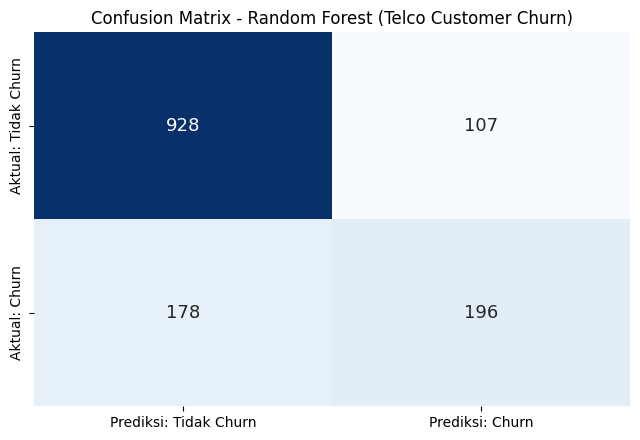


=== Metrik Evaluasi (fokus kelas 1 = Churn) ===
Accuracy               : 0.798
Precision (kelas Churn): 0.647
Recall    (kelas Churn): 0.524
F1-Score  (kelas Churn): 0.579

=== Kenapa Accuracy saja menyesatkan di sini ===
Akurasi model Random Forest                  : 0.798
Akurasi model 'malas' (tebak semua Tidak Churn): 0.735
Selisihnya cuma                              : 0.063

Pelanggan churn yang GAGAL terdeteksi (False Negative): 178 dari 374 pelanggan churn
Pelanggan setia yang salah dicap churn (False Positive) : 107


In [5]:
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score)
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_te, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Aktual: Tidak Churn", "Aktual: Churn"],
    columns=["Prediksi: Tidak Churn", "Prediksi: Churn"],
)
print("=== Confusion Matrix (bentuk tabel) ===")
print(cm_df)

plt.figure(figsize=(6.5, 4.5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False, annot_kws={"size": 13})
plt.title("Confusion Matrix - Random Forest (Telco Customer Churn)")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print("\n=== Metrik Evaluasi (fokus kelas 1 = Churn) ===")
print(f"Accuracy               : {accuracy_score(y_te, y_pred):.3f}")
print(f"Precision (kelas Churn): {precision_score(y_te, y_pred):.3f}")
print(f"Recall    (kelas Churn): {recall_score(y_te, y_pred):.3f}")
print(f"F1-Score  (kelas Churn): {f1_score(y_te, y_pred):.3f}")

# Pembanding: model "malas" yang menebak semua pelanggan tidak akan churn
baseline_acc = (y_te == 0).mean()
print("\n=== Kenapa Accuracy saja menyesatkan di sini ===")
print(f"Akurasi model Random Forest                  : {accuracy_score(y_te, y_pred):.3f}")
print(f"Akurasi model 'malas' (tebak semua Tidak Churn): {baseline_acc:.3f}")
print(f"Selisihnya cuma                              : {accuracy_score(y_te, y_pred) - baseline_acc:.3f}")
print(f"\nPelanggan churn yang GAGAL terdeteksi (False Negative): {fn} dari {tp + fn} pelanggan churn")
print(f"Pelanggan setia yang salah dicap churn (False Positive) : {fp}")

In [6]:
probabilitas_churn = rf.predict_proba(X_te)[:, 1]

hasil_evaluasi = pd.DataFrame({
    'Aktual': y_te,
    'Prediksi_Kelas': y_pred,
    'Probabilitas_Churn': probabilitas_churn
})

print("Contoh 5 Prediksi Probabilitas Teratas:")
print(hasil_evaluasi.head())

Contoh 5 Prediksi Probabilitas Teratas:
      Aktual  Prediksi_Kelas  Probabilitas_Churn
437        0               0            0.003333
2280       0               1            0.636667
2235       0               0            0.073333
4460       0               0            0.376667
3761       0               0            0.016667


### Interpretasi Hasil Evaluasi

Model Random Forest dengan parameter `class_weight="balanced"` digunakan untuk menangani masalah *imbalanced data* pada dataset Telco Churn, di mana proporsi pelanggan yang churn hanya **26.5%** berbanding **73.5%** pelanggan yang bertahan.

#### Kenapa Accuracy saja bisa menyesatkan?

Akurasi model terlihat lumayan di angka **0.798**, tapi angka ini menipu kalau dibaca sendirian. Karena 73.5% isi data uji adalah pelanggan yang tidak churn, sebuah model "malas" yang asal menebak **semua pelanggan tidak akan churn** tanpa belajar apa pun sudah otomatis mendapat akurasi **0.735**. Artinya seluruh kerja Random Forest ini hanya menambah **0.063** (6.3 poin) di atas model yang sebenarnya tidak berguna sama sekali — sebab model malas tadi tidak pernah bisa menunjuk satu pun pelanggan yang perlu diselamatkan. Inilah kenapa pada dataset imbalanced, Accuracy harus selalu dibandingkan dengan baseline kelas mayoritas.

#### Metrik mana yang paling relevan untuk kasus churn ini?

**Recall pada kelas Churn** adalah metrik yang paling relevan. Berdasarkan Confusion Matrix di atas, model masih melewatkan **178 dari 374** pelanggan yang benar-benar churn (*False Negative*). Setiap False Negative berarti satu pelanggan pergi tanpa sempat ditawari program retensi, padahal biaya mendapatkan pelanggan baru jauh lebih mahal daripada mempertahankan pelanggan lama. Nilai Recall kelas churn sebesar **0.524** menunjukkan model baru menangkap sekitar separuh pelanggan yang berisiko.

Sebagai pembanding, *False Positive* sebanyak **107** (pelanggan setia yang salah dicap akan churn) risikonya jauh lebih ringan: kerugiannya sebatas biaya promo yang terlanjur diberikan kepada orang yang sebenarnya tidak akan pergi. Karena itu untuk kasus churn kita rela menurunkan Precision demi menaikkan Recall, dan **F1-Score** (0.579) dipakai sebagai penyeimbang saat keduanya perlu dilihat sekaligus.

**ROC-AUC** sebesar **0.8337** juga lebih bisa dipercaya dibandingkan Accuracy, karena metrik ini mengukur kemampuan model memisahkan kedua kelas pada seluruh nilai *threshold*, sehingga tidak ikut terdongkrak oleh dominasi kelas mayoritas.

Melalui `predict_proba`, perusahaan dapat mengurutkan pelanggan berdasarkan probabilitas churn tertinggi untuk memprioritaskan program retensi, sekaligus menggeser *threshold* dari 0.5 ke angka yang lebih rendah bila ingin menaikkan Recall.

Apa yang dipelajari: Cara klasifikasi menggunakan algoritma ensemble (Random Forest), menangani kelas target yang jomplang (imbalanced) menggunakan parameter class_weight="balanced", mengukur keandalan model menggunakan metrik ROC-AUC, dan ekstrak nilai probabilitas dari prediksi (predict_proba).

Temuan utama: Random Forest lumayan praktis untuk mengatasi ketimpangan data tanpa perlu teknik sampling manual (kayak SMOTE) berkat fitur class weight. Lalu, hasil dari predict_proba memberikan insight seberapa "yakin" model terhadap tebakannya, jadi tidak hanya sekadar mengeluarkan angka 0 atau 1.

Pertanyaan yang muncul: Bagaimana cara melihat fitur atau kolom mana yang paling mempengaruhi untuk pelanggan churn (feature importance)? Lalu, apakah batas probabilitas 0.5 itu sudah yang paling pas atau threshold-nya perlu digeser agar tim bisnis tidak rugi memberikan promo ke pelanggan yang salah?